# HW01 2.1 理论计算题


### 1. 向量点积 $\boldsymbol{a} \cdot \boldsymbol{b}$
**计算规则**：同维度列向量点积 = 对应位置元素相乘后求和。
$$
\begin{align*}
\boldsymbol{a} \cdot \boldsymbol{b} &= 2 \times 1 + (-1) \times 4 + 3 \times (-2) \\
&= 2 - 4 - 6 \\
&= -8
\end{align*}
$$
**结果**：$\boldsymbol{a} \cdot \boldsymbol{b} = -8$

### 2. 矩阵乘法 $A \times B$


#### 步骤1：确定结果形状
- $A$ 维度：$2 \times 3$，$B$ 维度：$3 \times 2$ → 满足相乘条件，结果形状为 $2 \times 2$。

#### 步骤2：计算矩阵乘积
$$
\begin{align*}
A \times B &= \begin{bmatrix} 1 & 0 & 2 \\ -1 & 3 & 1 \end{bmatrix} \times \begin{bmatrix} 2 & 1 \\ 0 & -1 \\ 3 & 2 \end{bmatrix} \\
&= \begin{bmatrix}
1×2 + 0×0 + 2×3 & 1×1 + 0×(-1) + 2×2 \\
-1×2 + 3×0 + 1×3 & -1×1 + 3×(-1) + 1×2
\end{bmatrix} \\
&= \begin{bmatrix} 8 & 5 \\ 1 & -2 \end{bmatrix}
\end{align*}
$$
**结果**：
- 矩阵乘积：$A \times B = \begin{bmatrix} 8 & 5 \\ 1 & -2 \end{bmatrix}$；
- 结果形状：$2 \times 2$。

### 3. 向量 $\boldsymbol{a}$ 的 Frobenius 范数

$$
\begin{align*}
\|\boldsymbol{a}\|_F &= \sqrt{2^2 + (-1)^2 + 3^2} \\
&= \sqrt{4 + 1 + 9} \\
&= \sqrt{14} \approx 3.7417
\end{align*}
$$
**结果**：$\|\boldsymbol{a}\|_F = \sqrt{14} \approx 3.7417$


In [ ]:
#2.2 编程题
import numpy as np


# 创建 3×4 的标准正态分布随机矩阵 X

np.random.seed(42)  
X = np.random.randn(3, 4)
print("1. 形状为 3×4 的标准正态分布矩阵 X：")
print(X)
print("X 的形状：", X.shape)
print("-" * 50)


# 创建 4×2 的全 1 矩阵 Y

Y = np.ones((4, 2))
print("2. 形状为 4×2 的全 1 矩阵 Y：")
print(Y)
print("Y 的形状：", Y.shape)
print("-" * 50)


# 计算矩阵乘法 Z = X × Y

Z = np.matmul(X, Y)  # 用matmul保证矩阵乘法精度
print("3. 矩阵乘法结果 Z = X × Y：")
print(Z)
print("Z 的形状：", Z.shape)
print("-" * 50)


# 输出指定元素和行

# Z 的第一行和第二列交叉的元素
element = Z[0, 1]
# Z 的第 2 行所有元素
second_row = Z[1, :]

print("4. Z 的第一行、第二列交叉元素：", element)
print("   Z 的第 2 行所有元素：", second_row)
print("-" * 50)


# 计算 Z 的 Frobenius 范数

frobenius_norm = np.linalg.norm(Z, ord="fro")
print("5. Z 的 Frobenius 范数：", round(frobenius_norm, 4))

1. 形状为 3×4 的标准正态分布矩阵 X：
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
X 的形状： (3, 4)
--------------------------------------------------
2. 形状为 4×2 的全 1 矩阵 Y：
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Y 的形状： (4, 2)
--------------------------------------------------
3. 矩阵乘法结果 Z = X × Y：
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z 的形状： (3, 2)
--------------------------------------------------
4. Z 的第一行、第二列交叉元素： 2.5291682463487657
   Z 的第 2 行所有元素： [1.87835721 1.87835721]
--------------------------------------------------
5. Z 的 Frobenius 范数： 4.6169


# HW01 3.1 理论计算题

### 1. 疾病检测阳性时的患病概率（贝叶斯公式）
设事件 $A$ 为“患病”，事件 $B$ 为“检测结果为阳性”，已知：
- $P(A) = 0.1\% = 0.001$，$P(\neg A) = 0.999$
- $P(B|A) = 99\% = 0.99$（灵敏度）
- $P(B|\neg A) = 2\% = 0.02$（假阳性率）

$$
\begin{align*}
P(A|B) &= \frac{P(B|A)P(A)}{P(B|A)P(A) + P(B|\neg A)P(\neg A)} \\
&= \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.02 \times 0.999} \\
&= \frac{0.00099}{0.02097} \\
&\approx 0.0472
\end{align*}
$$
**结果**：检测为阳性时，真正患病的概率约为 $4.72\%$

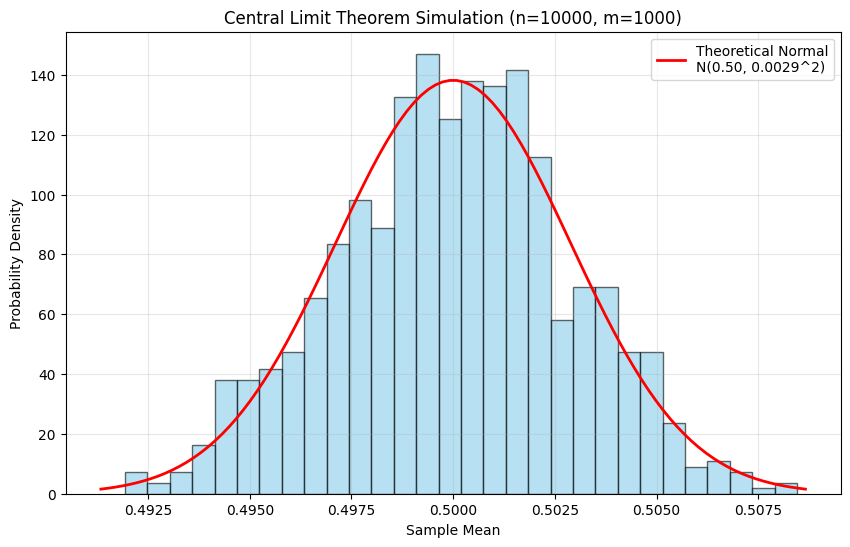

均值的实际方差： 0.00000828


In [7]:
#3.2 编程题
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 参数设置
n = 10000
m = 1000
np.random.seed(42)

# 生成随机变量并计算均值
means = []
for _ in range(m):
    samples = np.random.uniform(low=0.0, high=1.0, size=n)
    sample_mean = np.mean(samples)
    means.append(sample_mean)
means = np.array(means)

# 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

mu_theory = 0.5
sigma_theory = np.sqrt((1/12)/n)
x = np.linspace(mu_theory - 3*sigma_theory, mu_theory + 3*sigma_theory, 100)
pdf = norm.pdf(x, loc=mu_theory, scale=sigma_theory)
plt.plot(x, pdf, 'r-', lw=2, label=f'Theoretical Normal\nN({mu_theory:.2f}, {sigma_theory:.4f}^2)')

plt.title(f'Central Limit Theorem Simulation (n={n}, m={m})')
plt.xlabel('Sample Mean')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 计算均值的实际方差
actual_variance = np.var(means, ddof=0)
decimal_form = "{0:.8f}".format(actual_variance)
print("均值的实际方差：", decimal_form)

# HW01 4.1 理论计算题

### 1. 偏导数 $\frac{\partial z}{\partial w_1}$ 和 $\frac{\partial z}{\partial w_2}$ 的表达式

$$
\begin{align*}
\frac{\partial z}{\partial w_1} &= 2(w_1 x_1 + w_2 x_2 - y) \cdot x_1 \\
&= 2(2w_1 + w_2 - 3) \times 2 \\
&= 4(2w_1 + w_2 - 3)
\end{align*}
$$

$$
\begin{align*}
\frac{\partial z}{\partial w_2} &= 2(w_1 x_1 + w_2 x_2 - y) \cdot x_2 \\
&= 2(2w_1 + w_2 - 3) \times 1 \\
&= 2(2w_1 + w_2 - 3)
\end{align*}
$$

**结果：**
- $\frac{\partial z}{\partial w_1} = 4(2w_1 + w_2 - 3)$
- $\frac{\partial z}{\partial w_2} = 2(2w_1 + w_2 - 3)$

---

### 2. 当 $w_1 = 0.5, w_2 = 1$ 时的梯度值

$$
\begin{align*}
2w_1 + w_2 - 3 &= 2 \times 0.5 + 1 - 3 = -1 \\
\frac{\partial z}{\partial w_1} &= 4 \times (-1) = -4 \\
\frac{\partial z}{\partial w_2} &= 2 \times (-1) = -2
\end{align*}
$$

**结果：** 梯度值为 $\left( \frac{\partial z}{\partial w_1}, \frac{\partial z}{\partial w_2} \right) = (-4, -2)$

In [9]:
# 4.2 编程题
# 前向计算
x = 2
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2
print("前向传播结果 L:", L)

# 手动链式法则计算梯度
dL_db = 2 * b
dL_dw1 = dL_db * x
dL_dw2 = dL_db * 1

print("梯度 dL/dw1:", dL_dw1)
print("梯度 dL/dw2:", dL_dw2)

前向传播结果 L: 12.25
梯度 dL/dw1: 14.0
梯度 dL/dw2: 7.0


# HW01 5.1 理论计算题

### 1. 损失函数 $L$ 对 $w$ 的偏导数
$$
\begin{align*}
\frac{\partial L}{\partial w} &= \frac{\partial}{\partial w} \left( \frac{1}{n} \sum_{i=1}^n (y_i - (w x_i + b))^2 \right) \\
&= \frac{1}{n} \sum_{i=1}^n \frac{\partial}{\partial w} (y_i - w x_i - b)^2 \\
&= \frac{1}{n} \sum_{i=1}^n 2(y_i - w x_i - b) \cdot (-x_i) \\
&= -\frac{2}{n} \sum_{i=1}^n x_i \left( y_i - (w x_i + b) \right)
\end{align*}
$$
**结果**：$\frac{\partial L}{\partial w} = -\frac{2}{n} \sum_{i=1}^n x_i \left( y_i - (w x_i + b) \right)$

### 2. 损失函数 $L$ 对 $b$ 的偏导数
$$
\begin{align*}
\frac{\partial L}{\partial b} &= \frac{\partial}{\partial b} \left( \frac{1}{n} \sum_{i=1}^n (y_i - (w x_i + b))^2 \right) \\
&= \frac{1}{n} \sum_{i=1}^n \frac{\partial}{\partial b} (y_i - w x_i - b)^2 \\
&= \frac{1}{n} \sum_{i=1}^n 2(y_i - w x_i - b) \cdot (-1) \\
&= -\frac{2}{n} \sum_{i=1}^n \left( y_i - (w x_i + b) \right)
\end{align*}
$$
**结果**：$\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^n \left( y_i - (w x_i + b) \right)$

In [1]:
#5.2 编程题
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据
digits = load_digits()
X = digits.data
y = digits.target

# 数据划分与编码
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

# Softmax函数
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    n_samples = y_true.shape[0]
    logp = - np.log(y_pred[range(n_samples), y_true.argmax(axis=1)])
    loss = np.sum(logp)/n_samples
    return loss

# 参数初始化
n_features = X_train.shape[1]
n_classes = 10
lr = 0.1
batch_size = 32
epochs = 50
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

# 训练
for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train_onehot[indices]
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        
        logits = np.dot(X_batch, W) + b
        y_pred = softmax(logits)
        
        n = X_batch.shape[0]
        dlogits = (y_pred - y_batch) / n
        dW = np.dot(X_batch.T, dlogits)
        db = np.sum(dlogits, axis=0, keepdims=True)
        
        W -= lr * dW
        b -= lr * db
    
    logits_train = np.dot(X_train, W) + b
    y_pred_train = softmax(logits_train)
    train_loss = cross_entropy_loss(y_pred_train, y_train_onehot)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")

# 测试评估
logits_test = np.dot(X_test, W) + b
y_pred_test = softmax(logits_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
accuracy = np.mean(y_pred_labels == y_test)
print(f"Test Set Accuracy: {accuracy:.4f}")

Epoch 1, Train Loss: 1.1801
Epoch 2, Train Loss: 0.6558
Epoch 3, Train Loss: 1.4740
Epoch 4, Train Loss: 0.3124
Epoch 5, Train Loss: 0.2031
Epoch 6, Train Loss: 0.1896
Epoch 7, Train Loss: 0.0994
Epoch 8, Train Loss: 0.3062
Epoch 9, Train Loss: 0.1049
Epoch 10, Train Loss: 0.1576
Epoch 11, Train Loss: 0.1856
Epoch 12, Train Loss: 0.1393
Epoch 13, Train Loss: 0.0587
Epoch 14, Train Loss: 0.2124
Epoch 15, Train Loss: 0.4100
Epoch 16, Train Loss: 0.1577
Epoch 17, Train Loss: 0.3636
Epoch 18, Train Loss: 0.2863
Epoch 19, Train Loss: 0.0874
Epoch 20, Train Loss: 0.2857
Epoch 21, Train Loss: 0.1727
Epoch 22, Train Loss: 0.0664
Epoch 23, Train Loss: 0.0488
Epoch 24, Train Loss: 0.0340
Epoch 25, Train Loss: 0.2194
Epoch 26, Train Loss: 0.0461
Epoch 27, Train Loss: 0.0400
Epoch 28, Train Loss: 0.0216
Epoch 29, Train Loss: 0.0915
Epoch 30, Train Loss: 0.0236
Epoch 31, Train Loss: 0.0061
Epoch 32, Train Loss: 0.2986
Epoch 33, Train Loss: 0.1071
Epoch 34, Train Loss: 0.1384
Epoch 35, Train Loss: 0

# HW01 6.1 理论计算题

### 1. 似然函数 $L(\mu, \sigma^2)$
正态分布 $N(\mu, \sigma^2)$ 的概率密度函数为：
$$
f(x_i; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)
$$
样本 $x_1, x_2, \dots, x_n$ 独立同分布，似然函数为各密度的乘积：
$$
L(\mu, \sigma^2) = \prod_{i=1}^n f(x_i; \mu, \sigma^2) = \left( \frac{1}{2\pi\sigma^2} \right)^{\frac{n}{2}} \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2 \right)
$$

---

### 2. 证明 $\mu$ 的最大似然估计为 $\hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$
对数似然函数：
$$
\ell(\mu, \sigma^2) = \ln L(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2
$$
对 $\mu$ 求偏导并令其为0：
$$
\frac{\partial \ell}{\partial \mu} = -\frac{1}{2\sigma^2} \cdot 2\sum_{i=1}^n (x_i - \mu)(-1) = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0
$$
$$
\sum_{i=1}^n (x_i - \mu) = 0 \implies n\mu = \sum_{i=1}^n x_i \implies \hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i
$$

---

### 3. 证明 $\sigma^2$ 的最大似然估计为 $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2$
对 $\sigma^2$ 求偏导并令其为0：
$$
\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^n (x_i - \mu)^2 = 0
$$
$$
-\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^n (x_i - \mu)^2 = 0
$$
两边同乘 $2(\sigma^2)^2$：
$$
-n\sigma^2 + \sum_{i=1}^n (x_i - \mu)^2 = 0
$$
代入已得的 $\hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$：
$$
\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2
$$

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.0322
Epoch 200, Loss: 0.0208
Epoch 300, Loss: 0.0163
Epoch 400, Loss: 0.0138
Epoch 500, Loss: 0.0122
Epoch 600, Loss: 0.0111
Epoch 700, Loss: 0.0102
Epoch 800, Loss: 0.0095
Epoch 900, Loss: 0.0090
Test Accuracy: 1.0000


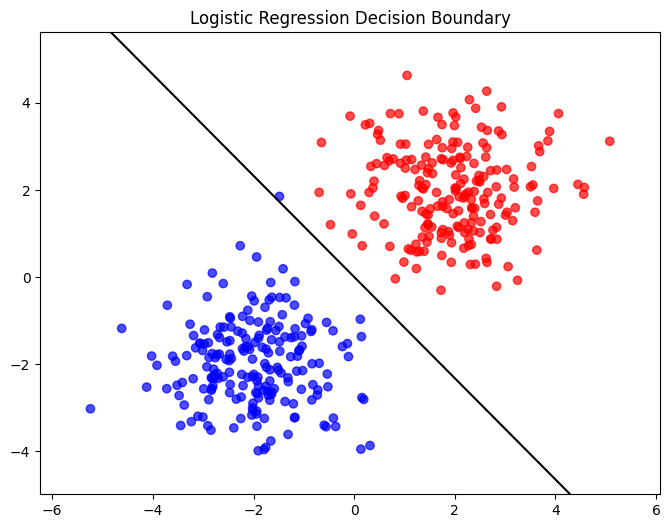

In [13]:
#6.2 编程题
import numpy as np
import matplotlib.pyplot as plt

# 生成数据
np.random.seed(42)
n_samples = 200
X1 = np.random.normal(loc=[-2, -2], scale=1, size=(n_samples, 2))
X2 = np.random.normal(loc=[2, 2], scale=1, size=(n_samples, 2))
X = np.vstack((X1, X2))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

# 定义sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失
def binary_cross_entropy(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

# 初始化参数
n_features = X.shape[1]
w = np.zeros(n_features)
b = 0
lr = 0.1
epochs = 1000

# 梯度下降训练
for epoch in range(epochs):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y, y_pred)
    dw = np.dot(X.T, (y_pred - y)) / len(y)
    db = np.mean(y_pred - y)
    w -= lr * dw
    b -= lr * db
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# 测试集评估
X1_test = np.random.normal(loc=[-2, -2], scale=1, size=(50, 2))
X2_test = np.random.normal(loc=[2, 2], scale=1, size=(50, 2))
X_test = np.vstack((X1_test, X2_test))
y_test = np.hstack((np.zeros(50), np.ones(50)))
z_test = np.dot(X_test, w) + b
y_pred_test = sigmoid(z_test)
y_pred_labels = (y_pred_test > 0.5).astype(int)
accuracy = np.mean(y_pred_labels == y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# 绘制决策边界
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.5], colors='black')
plt.title('Logistic Regression Decision Boundary')
plt.show()